<h1 style="font-size: 1.6rem; font-weight: bold">ITO 5221: Intelligent Image and Video Analysis</h1>
<h1 style="font-size: 1.6rem; font-weight: bold">Tutorial 1: Introduction to Intelligent Image and Video Analysis</h1>
<p style="margin-top: 5px; margin-bottom: 5px;">Monash University Australia</p>
<p style="margin-top: 5px; margin-bottom: 5px;">Jupyter Notebook by: Tristan Sim Yook Min</p>
References: Information Source from Monash Faculty of Information Technology

---

### **Task 1**
#### **1.A. Open an image and display it using a plot**

For image processing some standard modules are: 
- skimage: Contains many image processing algorithms
- opencv: Open source computer vision library (have many CV predefined algortihms)
- matplotlib: Standard library to create interactive visualisations in python.

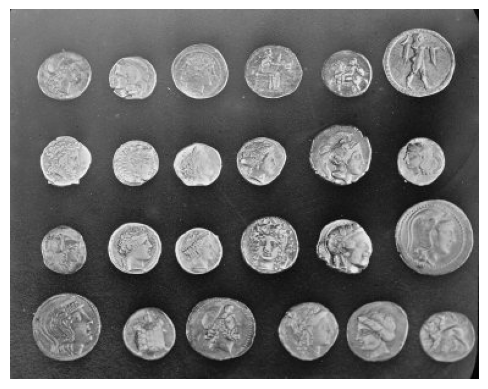

In [1]:
# Import the Skimage to Load the Image Data
from skimage import data
import matplotlib.pyplot as plt

# Load some image from 'skimage.data.coins()' and display the images using 'matplotlib.pyplot'
input_image = data.coins()
plt.imshow(input_image, cmap="gray")
plt.axis('off')
plt.show()

#### **1.B. Open an image from the System**

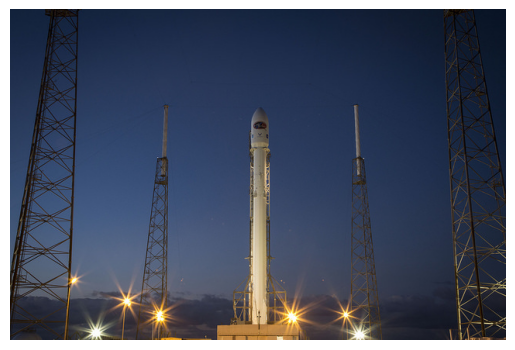

Image Height: 427 
Image Width: 640 
Number of Channels: 3


In [15]:
# Read an image stored in your system using skimage.io and plot the image
input_image = plt.imread(r'Data\Rocket.jpg')
plt.imshow(input_image)
plt.axis('off')
plt.show()
height, width, depth = input_image.shape

# Check the dimensions of the image
print('Image Height:', height, '\nImage Width:', width, '\nNumber of Channels:', depth)

***



### **Task 2**

Access Pixel-Level Information and Copy the Content of an Input Image into the Left Part of a New Image.

In [18]:
import numpy as np

# Read the image and extract dimensions of the image
height, width, depth = input_image.shape
print('Image Height: ', height, 'Image Width: ', width, 'Image Depth: ', depth)

# Create a new blank image as same size of the input image
# depth above applies to the number of channels. Generally, single channel images are grayscale
output_image = np.zeros([height, width, depth])

# Copy pixel value across three channels

# Display the orignal and new image together
def task2_show(in_img, out_img):
    fig, axes = plt.subplots(1, ncols=2, figsize=(8, 4))  # Two figures
    axes[0].imshow(in_img)
    axes[0].axis('off')
    axes[0].set_title('original image')
    axes[1].imshow(out_img / 255)
    axes[1].axis('off')
    axes[1].set_title('Image after copying left half')
    plt.show()

Image Height:  427 Image Width:  640 Image Depth:  3


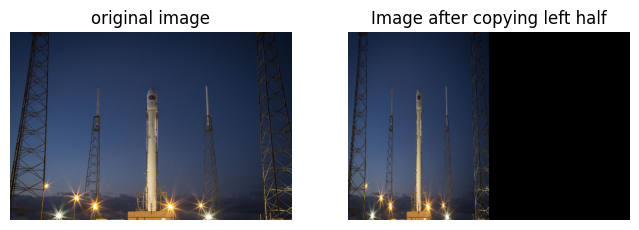

CPU times: total: 422 ms
Wall time: 424 ms


In [24]:
%%time
# Copy pixel value across three channels
# Please note that this operation can be performed in any manner. 
for row in range(0, height):
    for col in range(0, width):
        for channel in range(0, depth):
            output_image[row, int(col / 2), channel] = input_image[row, col, channel]

task2_show(input_image, output_image)

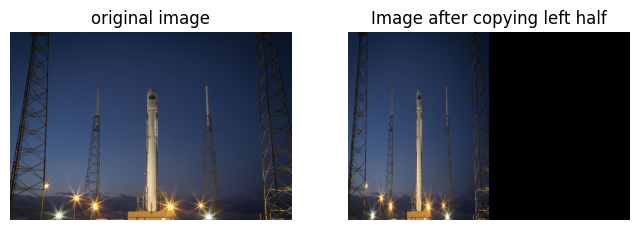

CPU times: total: 93.8 ms
Wall time: 90 ms


In [26]:
%%time
height, width, depth = input_image.shape
output_image = np.zeros([height, width, depth])
output_image[:, :width // 2] = input_image[:, ::2]
task2_show(input_image, output_image)

***



### **Task 3**

#### **Input an image and perform the point operations on gray scale value I to increase/decrease contrast and brightness of an image.**

In point operation, each pixel of an image is accessed sequentially and the operation above is applied. Generate four output images based on the four point operations mentioned.
Hint: for converting RGB to grayscale use `rgb2gray(image)` from `skimage.color`
Note that point operators can lead to pixel values go out of range, this requires to be handled.

Mathematically, point operation can be applied as
$$g(x) = a \cdot f(x) + b$$
where, $f$ is the image function, a>0 is gain (contrast), b is bias (brightness)

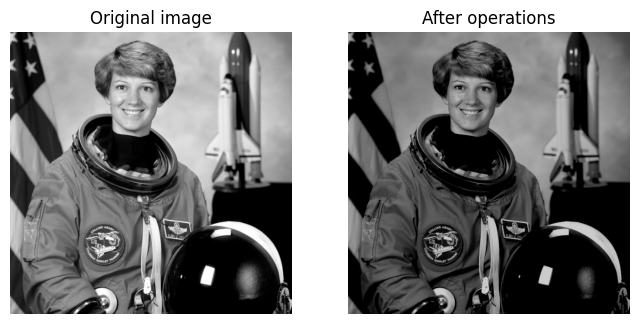

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
from skimage.color import rgb2gray
from skimage import data

# Create a function apply_operations() which will apply the point operation
# function applies contrast changing
def multiply(value, factor):
    return np.clip(value * factor, 0, 255)

# function applies brightness changing
def add(value, factor):
    return np.clip(value + factor, 0, 255)

def apply_operations(image, method, factor):
    image = method(image, factor)
    return image.astype(int)

input_image = data.astronaut()
gray_image = (rgb2gray(input_image) * 255).astype(int)  # Convert RGB image into gray scale
factor = -50  # Value of point operator, we can change this value to check its effect on the output images
output_image = apply_operations(gray_image, add, factor)

# Plot original and modified image
fig, axes = plt.subplots(1, ncols=2, figsize=(8, 4))
axes[0].imshow(gray_image, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original image")
axes[0].axis("off")
axes[1].imshow(output_image, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("After operations")
axes[1].axis("off")
plt.show()

***

### **Task 4: Plot histogram and calculate L1 distance**

Histogram of an image can directly be displayed using a matplotlib function.`plt.hist()` computes the histogram of the given input image.

Input arguments are 
- `x` - 1D array
- `bins` - to specify the bins used

It returns value of histogram bins, edges of bins and patches (Only value of histogram bins is used in this example)

#### **Task 4.1: L1 between Astronaut and Chelsea**

Please use two images from `skimage.data.astronaut()` and `skimage.data.chelsea()`.

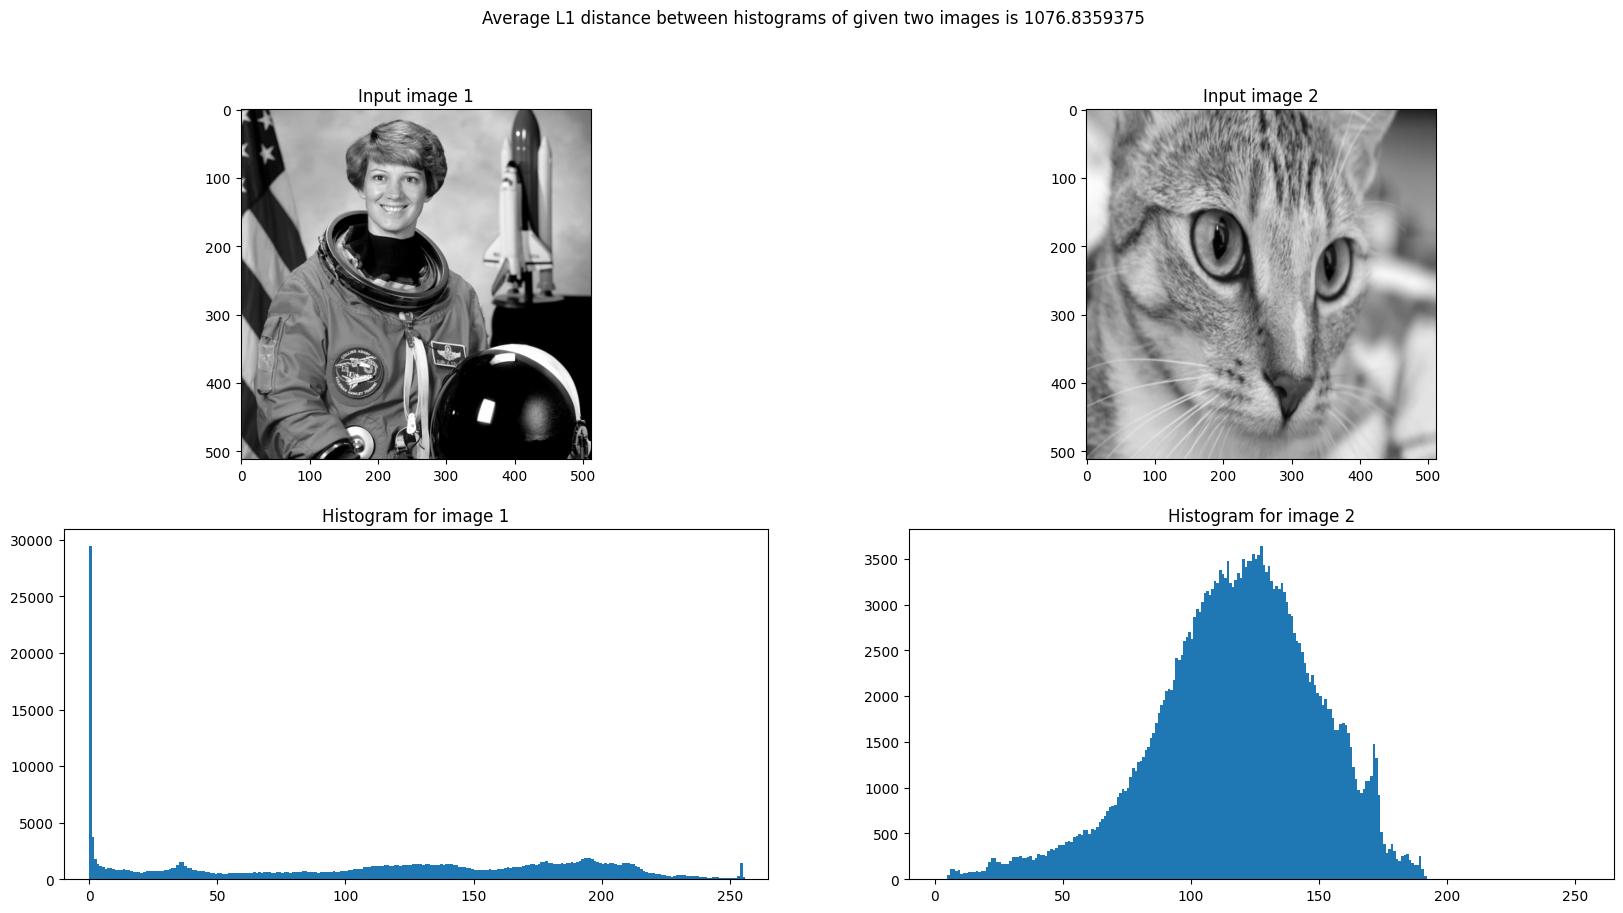

In [28]:
from skimage import data  # To input standard images
from matplotlib import pyplot as plt
from skimage.color import rgb2gray  # To convert RGB image to grayscale
from skimage.transform import rescale, resize, downscale_local_mean, rotate  # Image transforms

# Load two different images and convert them to grayscale
input_image1 = rgb2gray(data.astronaut()) * 255
input_image2 = rgb2gray(data.chelsea()) * 255

# Resize images to be of same size
input_image2 = resize(input_image2, input_image1.shape)

# Plot the images with their histograms. 
# example - plt.hist(image.ravel(), bins= num_bins) 
# ravel() is used to get a flattened array. Used to convert RGB image to 1D array

# bins defines the number of equal-width bins in the range
fig, axarr = plt.subplots(2, 2, figsize=(20, 10))
axarr[0, 0].imshow(input_image1.astype(int), cmap='gray')
axarr[0, 0].set_title('Input image 1')
axarr[0, 1].imshow(input_image2.astype(int), cmap='gray')
axarr[0, 1].set_title('Input image 2')

# bins defines the number of equal-width bins in the range
res = axarr[1, 0].hist(input_image1.ravel(), bins=256, range=(0, 256))
hist_arr1 = res[0]
axarr[1, 0].set_title('Histogram for image 1')
axarr[1, 0].axis(xmin=-10, xmax=265)
hist_arr2 = axarr[1, 1].hist(input_image2.ravel(), bins=256, range=(0, 256))[0]
axarr[1, 1].set_title('Histogram for image 2')
axarr[1, 1].axis(xmin=-10, xmax=265)

# Compute the L1 distance between the histogram arrays
# L1 distance is the sum of absolute difference
l1_distance = np.abs(hist_arr1 - hist_arr2).mean()
fig.suptitle('Average L1 distance between histograms of given two images is ' + str(l1_distance))
plt.show()

#### **Task 4.2: Apply point operation to an image. Plot histogram of original image and image obtained after applying point operations. Calculate the L1 distance between them.**

$$L_1(a, b) = \sum_{i=1}^{n}{|a_i - b_i|}$$

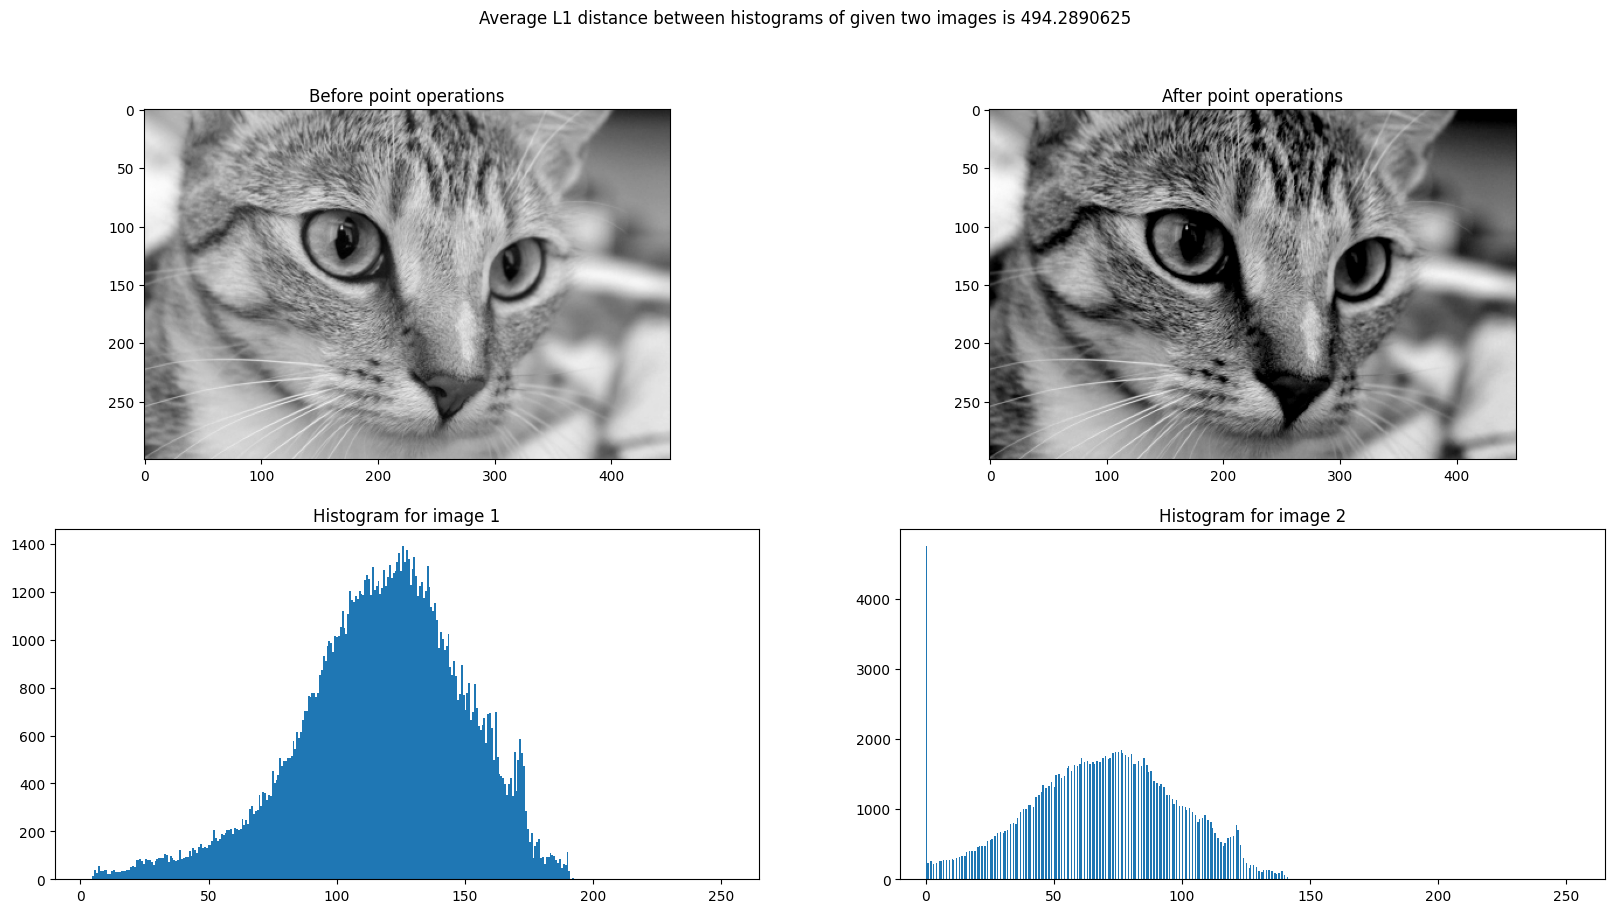

In [29]:
factor = -50
input_image1 = rgb2gray(data.chelsea()) * 255  # Mapping betwen [0-255]
input_image2 = apply_operations(input_image1, add, factor)  # Point operator is applied to grayscale input_image1

fig, axarr = plt.subplots(2, 2, figsize=(20, 10))
axarr[0, 0].imshow(input_image1.astype(int), cmap='gray')
axarr[0, 0].set_title('Before point operations')
axarr[0, 1].imshow(input_image2.astype(int), cmap='gray')
axarr[0, 1].set_title('After point operations')
hist_arr1 = axarr[1, 0].hist(input_image1.ravel(), bins=256)[0]
axarr[1, 0].set_title('Histogram for image 1')
axarr[1, 0].axis(xmin=-10, xmax=265)
hist_arr2 = axarr[1, 1].hist(input_image2.ravel(), bins=256)[0]
axarr[1, 1].set_title('Histogram for image 2')
axarr[1, 1].axis(xmin=-10, xmax=265)

l1_distance = np.abs(hist_arr1 - hist_arr2).mean()
fig.suptitle('Average L1 distance between histograms of given two images is ' + str(l1_distance))
plt.show()

***

### **Task 5: Morphological Operators**

#### **Task 5.1: Erosion and dilation**

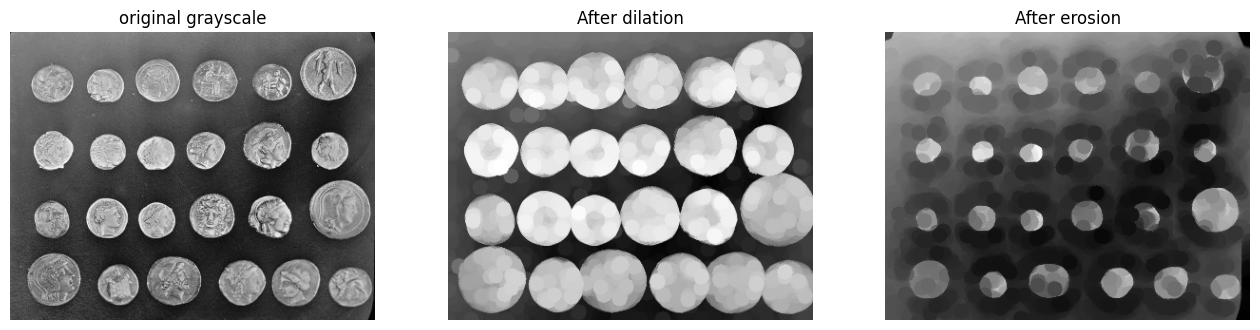

In [30]:
from skimage import data  # for inbuilt images
from skimage.morphology import erosion, dilation, disk  # for morphological operators and masks
import matplotlib.pyplot as plt

# Some examples of mask are - disk(), rectangle(), diamond(), octagon()
# Input an image and convert it into grayscale
gray_image = data.coins()  # coin is a standard image with gray scale, so no need for convert

# Apply dilation operation.
# Syntax is - dilation(binary_input_image,mask(size_of_mask))
# Mask is the structuring element. One example is disk(size)
dilated_image = dilation(gray_image, disk(8))

# Apply erosion operation
# Syntax is erosion(binary_input_image, mask(size_of_mask))
# Mask is the structuring element. One example is disk(size)
eroded_image = erosion(gray_image, disk(8))

# Display original image, image after dilation and image after erosion
fig, axes = plt.subplots(1, ncols=3, figsize=(16, 8))
axes[0].imshow(gray_image, cmap='gray')
axes[0].axis('off')
axes[0].set_title('original grayscale')
axes[1].imshow(dilated_image, cmap='gray')
axes[1].axis('off')
axes[1].set_title('After dilation')
axes[2].imshow(eroded_image, cmap='gray')
axes[2].axis('off')
axes[2].set_title('After erosion')
plt.show()

#### **Task 5.2: Opening**

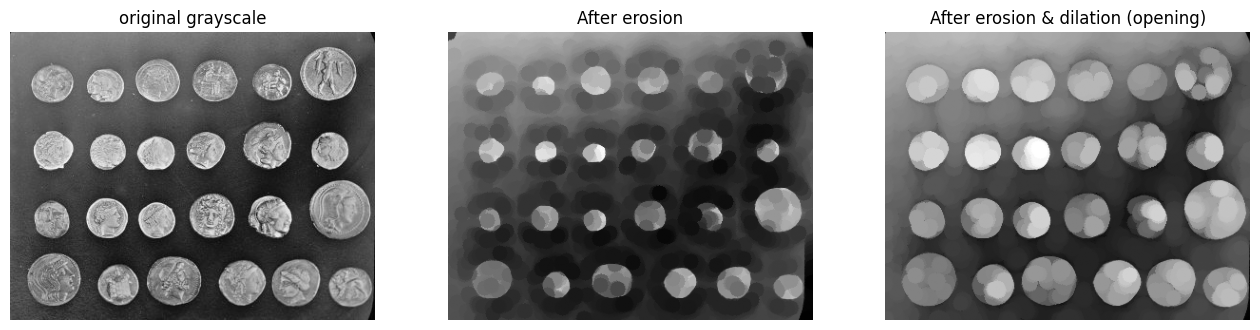

In [31]:
## Erode then dilate
opening_ero = erosion(gray_image, disk(8))  # Try with different images, masks, and mask size
opening_dil = dilation(opening_ero, disk(8))

# Display original image and image after opening
fig, axes = plt.subplots(1, ncols=3, figsize=(16, 8))
axes[0].imshow(gray_image, cmap='gray')
axes[0].axis('off')
axes[0].set_title('original grayscale')
axes[1].imshow(opening_ero, cmap='gray')
axes[1].axis('off')
axes[1].set_title('After erosion')
axes[2].imshow(opening_dil, cmap='gray')
axes[2].axis('off')
axes[2].set_title('After erosion & dilation (opening)')
plt.show()

#### **Task 5.3: Closing**

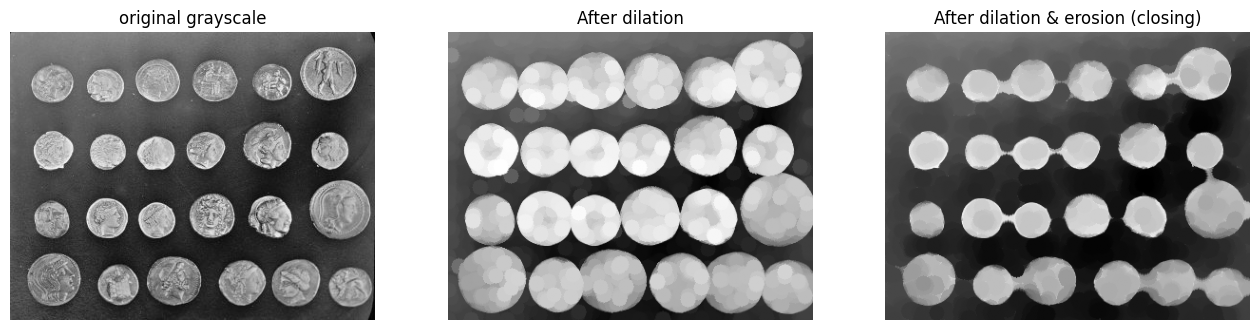

In [32]:
## Dilate then erode
# Try with different images, masks, and mask size
closing_dil = dilation(gray_image, disk(8))  # Try with different images, masks, and mask size
closing_ero = erosion(closing_dil, disk(8))

# Display original image and image after opening
fig, axes = plt.subplots(1, ncols=3, figsize=(16, 8))
axes[0].imshow(gray_image, cmap='gray')
axes[0].axis('off')
axes[0].set_title('original grayscale')
axes[1].imshow(closing_dil, cmap='gray')
axes[1].axis('off')
axes[1].set_title('After dilation')
axes[2].imshow(closing_ero, cmap='gray')
axes[2].axis('off')
axes[2].set_title('After dilation & erosion (closing)')
plt.show()

### **Task 6: Edge Detection**

In [33]:
# Importing necessary libraries
from skimage.feature import canny  # For canny()
from skimage.filters import sobel, gaussian  # For in built filters such as gaussian, sobel
from skimage.color import rgb2gray
import matplotlib.pyplot as plt
from skimage import data

# input image and convert to gray (if RGB)
input_img = data.astronaut()
input_img = rgb2gray(input_img)  # Optional

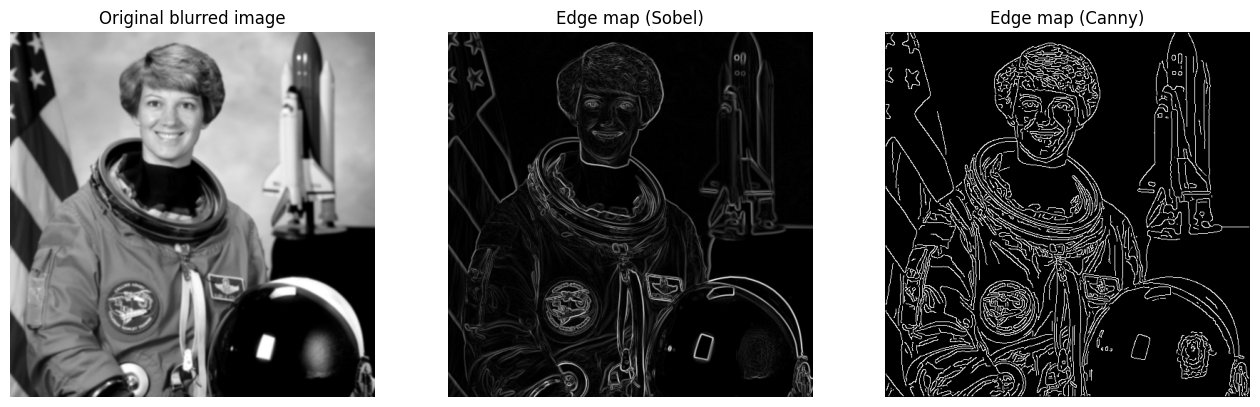

In [34]:
# Apply sobel operator and canny edge detection to the same image.
# Display the original image, edge map from sobel and from canny

# TODO - Apply canny and sobel operations
# Syntax - canny(image) - import from skimage.feature
# Syntax - sobel(image) - import from skimage.filters
edge_map_canny = canny(input_img)
edge_map_sobel = sobel(input_img)

# TODO - Display original blurred image, output of sobel and canny detection
fig, axes = plt.subplots(1, ncols=3, figsize=(16, 8))
axes[0].imshow(gaussian(input_img), cmap='gray')
axes[0].axis('off')
axes[0].set_title('Original blurred image')
axes[1].imshow(edge_map_sobel, cmap='gray')
axes[1].axis('off')
axes[1].set_title('Edge map (Sobel)')
axes[2].imshow(edge_map_canny, cmap='gray')
axes[2].axis('off')
axes[2].set_title('Edge map (Canny)')
plt.show()

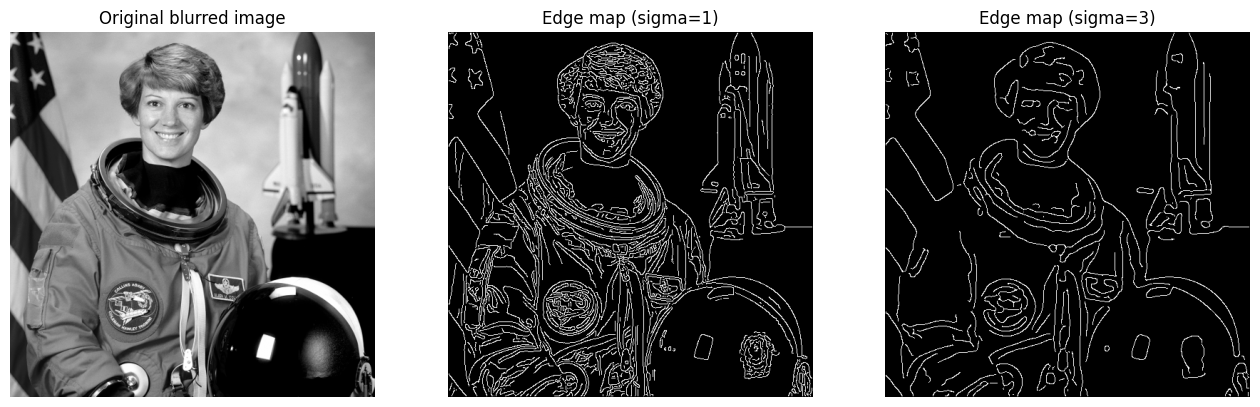

In [35]:
# Apply canny edge detection to the same image with different value of sigma
# Analyse the effect of sigma on the output.

# Syntax - canny(image, sigma=...)

# TODO - Apply canny edge detection on the same image but change the sigma value for the 2nd case
edge_map = canny(input_img, sigma=1)
edge_map2 = canny(input_img, sigma=3)
# Also check the output after changing the low and high threshold

# TODO - Display the original image and edge maps obtained after using different sigma values
fig, axes = plt.subplots(1, ncols=3, figsize=(16, 8))
axes[0].imshow(input_img, cmap='gray')
axes[0].axis('off')
axes[0].set_title('Original blurred image')
axes[1].imshow(edge_map, cmap='gray')
axes[1].axis('off')
axes[1].set_title('Edge map (sigma=1)')
axes[2].imshow(edge_map2, cmap='gray')
axes[2].axis('off')
axes[2].set_title('Edge map (sigma=3)')
plt.show()